# Lecture 3 - Demo Notebook Part 1

This notebook focuses on classification, using the same flipped classroom data as for the regression model lecture (lecture 2). The second part of the lecture on model evaluation can be found in a separate notebook. 

## Prelimilaries: Imports and stuff

In [19]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score, balanced_accuracy_score
from sklearn.preprocessing import MinMaxScaler, normalize
from sklearn.linear_model import LogisticRegression

import statsmodels.api as sm
import statsmodels.formula.api as smf

from scipy.spatial.distance import pdist, cdist, squareform

# Data directory
DATA_DIR = "./course_data"

# Section 1: Pre-processing

## Read the data

In [20]:
# Parse the aggregated data frame
df_lq = pd.read_csv('{}/aggregated_extended_fc.csv'.format(DATA_DIR))

## Clean the data

### We remove inactive students that did not click during weekdays and weekend for the first 5 weeks of the semester.

In [21]:
def remove_inactive_students(df, ts):
    df = df.fillna('NaN')
    
    #find all users weeks with 0 clicks on weekends and 0 clicks on weekdays during the first weeks of the semester
    df_first = ts[ts.week < 5]
    rows = np.where(np.logical_and(df_first.ch_total_clicks_weekend==0, df_first.ch_total_clicks_weekday == 0).to_numpy())[0]
    df_zero = df_first.iloc[rows,:]
    dropusers = np.unique(df_zero.user)

    ts = ts[ts.user.isin(dropusers)==False]
    df = df[df.user.isin(dropusers)==False]
    return df, ts

df_lq, ts = remove_inactive_students(df_lq, ts)
# print(df_lq.columns)


In [22]:
display(df_lq)

,user,ch_num_sessions,ch_time_in_prob_sum,ch_time_in_video_sum,ch_ratio_clicks_weekend_day,ch_total_clicks_weekend,ch_total_clicks_weekday,ch_time_sessions_mean,ch_time_sessions_std,bo_delay_lecture,...,la_weekly_prop_watched_mean,la_weekly_prop_interrupted_mean,la_weekly_prop_interrupted_std,la_weekly_prop_replayed_mean,la_weekly_prop_replayed_std,la_frequency_action_video_play,grade,gender,category,year
0,0,1.9,2334.4,2951.8,0.850000,16.8,38.1,1392.858333,790.762032,55068.387500,...,0.245714,0.024286,0.0,0.010000,0.0,0.179203,4.50,NaN,NaN,Y2-2018-19
1,1,3.4,1698.4,9227.8,0.567500,4.0,179.4,3068.720238,1257.504407,-2883.367738,...,0.748868,0.074683,0.0,0.066456,0.0,0.332424,4.50,M,Suisse.Autres,Y2-2018-19
2,2,5.3,2340.6,10801.3,26.562274,94.6,129.2,1750.289268,1024.134043,10027.216667,...,0.354487,0.026667,0.0,0.059915,0.0,0.284407,5.25,M,Suisse.PAM,Y2-2018-19
3,3,2.8,2737.1,8185.5,3.691250,13.5,46.4,20203.590260,656.052901,27596.864484,...,0.370000,0.014286,0.0,0.020000,0.0,0.108774,4.50,F,Suisse.Autres,Y2-2018-19
4,4,2.5,3787.3,7040.0,1.543889,58.4,64.9,3373.908333,1363.320365,-914.633333,...,0.030000,0.000000,0.0,0.020000,0.0,0.199775,4.75,F,France,Y2-2018-19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,293,3.5,8127.5,113.4,0.632304,28.9,20.6,7963.627500,1001.514794,0.000000,...,0.000000,0.000000,0.0,0.000000,0.0,0.034080,5.25,M,France,Y3-2019-20
284,294,2.2,2452.4,4623.1,18.147762,36.4,71.3,3614.055952,853.195566,16834.900000,...,0.140530,0.011111,0.0,0.000000,0.0,0.186649,5.25,F,France,Y3-2019-20
285,296,0.9,1643.2,1932.4,0.000000,0.4,31.2,926.916667,616.918475,-12860.522222,...,0.069231,0.023077,0.0,0.000000,0.0,0.028596,6.00,F,France,Y3-2019-20
286,297,1.4,2718.6,360.3,0.180000,2.0,15.3,346.437500,122.017326,0.000000,...,0.000000,0.000000,0.0,0.000000,0.0,0.032353,5.00,M,Suisse.PAM,Y3-2019-20


In [23]:
display(ts)

,week,user,ch_num_sessions,ch_time_in_prob_sum,ch_time_in_video_sum,ch_ratio_clicks_weekend_day,ch_total_clicks_weekend,ch_total_clicks_weekday,ch_time_sessions_mean,ch_time_sessions_std,...,la_seek_len_std,la_pause_dur_std,la_time_speeding_up_mean,la_time_speeding_up_std,la_weekly_prop_watched_mean,la_weekly_prop_interrupted_mean,la_weekly_prop_interrupted_std,la_weekly_prop_replayed_mean,la_weekly_prop_replayed_std,la_frequency_action_video_play
1,0,1,7.0,326.0,15525.0,5.675000,40.0,227.0,1931.285714,1648.472515,...,146.564097,188.175709,65.173554,150.807752,0.6,0.1,0.0,0.0,0.0,0.400749
2,0,2,4.0,1224.0,12209.0,258.000000,1.0,258.0,2780.250000,2297.110400,...,33.419147,39.702700,0.000000,0.000000,0.6,0.0,0.0,0.0,0.0,0.370656
4,0,4,4.0,1294.0,12037.0,0.328571,140.0,46.0,3043.750000,344.374342,...,159.612354,228.274335,67.941176,111.514074,0.3,0.0,0.0,0.2,0.0,0.252688
5,0,5,2.0,1324.0,4440.0,0.000000,119.0,0.0,2882.000000,2827.000000,...,99.684654,182.336877,51.760000,146.965446,0.0,0.0,0.0,0.0,0.0,0.411765
6,0,6,3.0,1773.0,14462.0,1.411765,102.0,144.0,5411.666667,2459.581039,...,116.878539,135.989183,0.000000,0.000000,0.6,0.1,0.0,0.0,0.0,0.353659
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2864,9,281,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000
2868,9,285,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000
2869,9,286,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000
2873,9,291,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000


## Prepare data for classification  

### Add a pass/fail label 

In [24]:
# We first add a column to the dataframe containing the outcome variable
# compute pass/fail label
df_lq['passed'] = df_lq.grade >= 4
df_lq['passed'] = df_lq['passed'].astype(int)

### Remove "bad" features and Split Data

In [25]:
# We then split the data in a train-test split (stratified by the outcome variable)
X = df_lq.drop(['user','grade', 'gender', 'category', 'year', 'passed'], axis=1)
y = df_lq['passed']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y) # split train and validation data set

### Print pass/fail proportions

In [26]:
# The class proportions in train and validation sets are the same, thanks to the stratification on y
print(y_train.value_counts(normalize=True))
print(y_val.value_counts(normalize=True))

passed
1    0.6
0    0.4
Name: proportion, dtype: float64
passed
1    0.603448
0    0.396552
Name: proportion, dtype: float64


## Define Evaluation Metrics

We will use the accuracy and AUC for evaluation for all classifiers.

In [27]:
def compute_scores(clf, X_train, y_train, X_test, y_test, roundnum = 3):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy =  balanced_accuracy_score(y_test, y_pred)
    
    y_pred_proba = clf.predict_proba(X_test)[:,1]
    auc = roc_auc_score(y_test, y_pred_proba)
    
    return round(accuracy,roundnum), round(auc,roundnum)

# Section 2: Decision Trees

### Compute a decision tree of max depth 2  over all the features

In [28]:
clf = tree.DecisionTreeClassifier(max_depth=2, random_state=0, criterion='entropy')
accuracy, auc = compute_scores(clf, X_train, y_train, X_val, y_val)
print("Decision tree. Balanced Accuracy = {}, AUC = {}".format(accuracy, auc))

Decision tree. Balanced Accuracy = 0.545, AUC = 0.584


### Visualize the decision tree

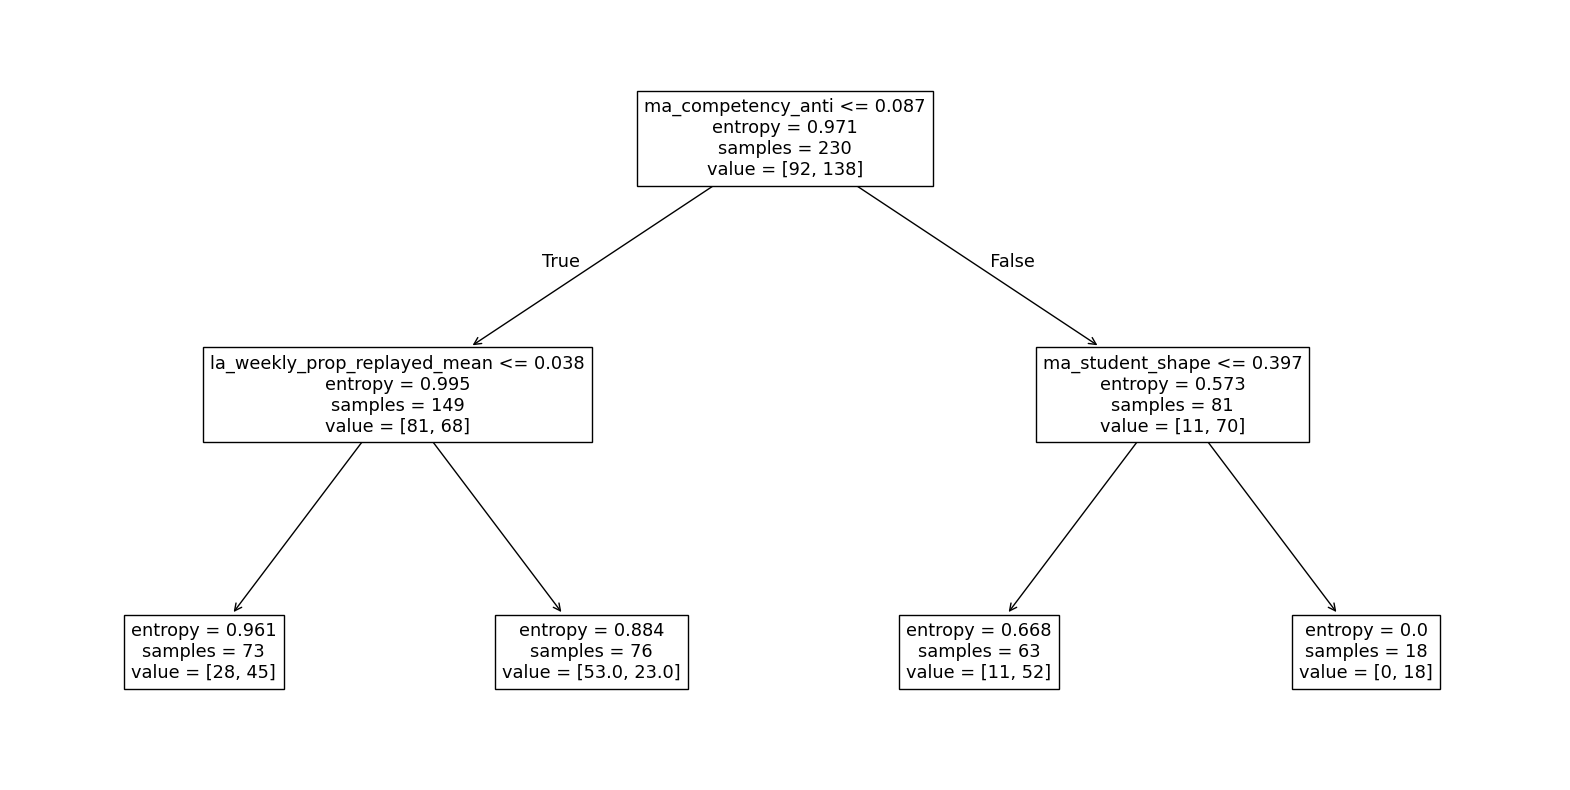

In [29]:
plt.figure(figsize=(20, 10))
tree.plot_tree(clf, feature_names=X_train.columns);

### Does depth improves performance ?

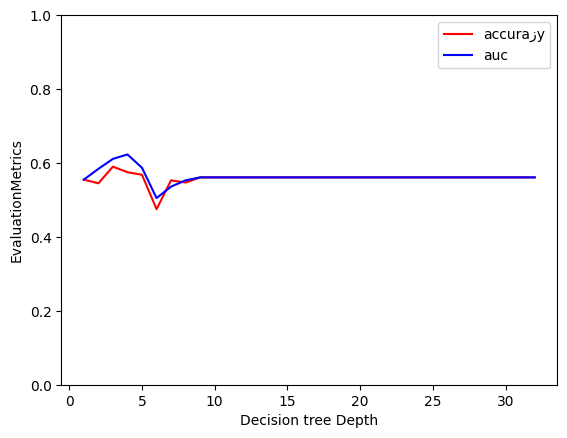

In [30]:
# We can change the max depth
accuracy_list = []
auc_list = []
for depth in range(1,len(X_train.columns)):
    clf = tree.DecisionTreeClassifier(max_depth=depth, random_state=0, criterion='entropy')
    accuracy, auc = compute_scores(clf, X_train, y_train, X_val, y_val)
    accuracy_list.append(accuracy)
    auc_list.append(auc)
    # print("Decision tree. Depth = {}, Balanced Accuracy = {}, AUC = {}".format(depth, accuracy, auc))
x = list(range(1,len(X_train.columns)))
plt.plot(x, accuracy_list, 'r', label = 'accuraزy')
plt.plot(x, auc_list, 'b', label = 'auc')
plt.xlabel("Decision tree Depth")
plt.ylabel("EvaluationMetrics")
plt.ylim([0,1])
plt.legend()
plt.show()

# Section 3: Random Forests

Next, we will use a random forest classifier instead of a decision tree.

In [31]:
rf = RandomForestClassifier(n_estimators=100, random_state=0, criterion='entropy') # create a Random Forest
accuracy, auc = compute_scores(rf, X_train, y_train, X_val, y_val)
print("Random Forest. Balanced Accuracy = {}, AUC = {}".format(accuracy, auc))

Random Forest. Balanced Accuracy = 0.61, AUC = 0.615


For a single tree, in fact, keeping a low depth is necessary to avoid overfitting and to reduce the variance. Random forests, instead, can have a higher depth, and consequently a lower bias, since the variance is reduced in the aggregation step.

In this case, decision trees seem to perform better than random forests. A reason for this behavior could be that the single tree is already very "stable", i.e. it will change a little in response to little changes in the data. If this was the case, the submodels in the ensemble forest would be all very similar to the single tree, if they were allowed to choose among all the features at every split. Since, though, only a random subset of features is considered at each split, some subtrees would choose bad splits and have overall bad performances.

# Section 4: K-Nearest Neighbors

We only use the euclidean distance since all our features are numerical

In [32]:
feature = 'ch_time_in_prob_sum'

# Compute the pairwise distance matrix for all the elements of the training set
X_train_dist = squareform(pdist(X_train[feature].to_numpy().reshape(-1,1), metric='euclidean'))

# Compute the distance between all elements of the training set and of the validation set
X_val_dist = cdist(X_val[feature].to_numpy().reshape(-1,1), X_train[feature].to_numpy().reshape(-1,1), metric='euclidean')

X_train_dist

array([[   0. , 4359.1, 1662.4, ...,   51.2, 5411.2, 3073.2],
       [4359.1,    0. , 2696.7, ..., 4307.9, 1052.1, 1285.9],
       [1662.4, 2696.7,    0. , ..., 1611.2, 3748.8, 1410.8],
       ...,
       [  51.2, 4307.9, 1611.2, ...,    0. , 5360. , 3022. ],
       [5411.2, 1052.1, 3748.8, ..., 5360. ,    0. , 2338. ],
       [3073.2, 1285.9, 1410.8, ..., 3022. , 2338. ,    0. ]],
      shape=(230, 230))

In [33]:
print('Training set size:', X_train.shape)
print('Validation set size:', X_val.shape)
print('Training pairwise distances size:', X_train_dist.shape)
print('Validation distances size:', X_val_dist.shape)

Training set size: (230, 33)
Validation set size: (58, 33)
Training pairwise distances size: (230, 230)
Validation distances size: (58, 230)


In [34]:
knn = KNeighborsClassifier(n_neighbors=5, metric='precomputed')

accuracy, auc = compute_scores(knn, X_train_dist, y_train, X_val_dist, y_val)
print("k-nearest neighbors. Balanced Accuracy = {}, AUC = {}".format(accuracy, auc))

k-nearest neighbors. Balanced Accuracy = 0.596, AUC = 0.629


# Section 5: Logistic regression

We normalize the data data using the MinMaxScaler such that all the features are on the same scale.

In [35]:
scaler = MinMaxScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_val_scaled  = scaler.transform(X_val)

clf = LogisticRegression(random_state=0)
accuracy, auc = compute_scores(clf, X_train_scaled, y_train, X_val_scaled, y_val)
print("Logistic Regression. Balanced Accuracy = {}, AUC = {}".format(accuracy, auc))

Logistic Regression. Balanced Accuracy = 0.56, AUC = 0.605
